In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Configure plot styles
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

## 1. Dataset Loading & Inspection


In [2]:
data_path = 'data/water_purification_dataset.csv' if os.path.exists('data/water_purification_dataset.csv') else 'water_purification_dataset.csv'
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")
print("\nHead of Dataset:")
print(df.head())

Dataset Shape: (1200, 11)

Head of Dataset:
     pH  turbidity_NTU  ...  filter_replacement  maintenance_required
0  7.14           7.62  ...                   1                     0
1  8.84           0.29  ...                   0                     1
2  8.23           0.33  ...                   1                     0
3  7.87           3.36  ...                   1                     0
4  6.46           4.95  ...                   0                     1

[5 rows x 11 columns]


In [3]:
print("--- Dataset Information ---")
print(df.info())
print("\n--- Missing Values Audit ---")
print(df.isnull().sum())
print("\n--- Target Class Distribution (water_quality) ---")
print(df['water_quality'].value_counts())

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pH                        1200 non-null   float64
 1   turbidity_NTU             1200 non-null   float64
 2   TDS_ppm                   1200 non-null   int64  
 3   flow_rate_L_min           1200 non-null   float64
 4   pressure_bar              1200 non-null   float64
 5   temperature_C             1200 non-null   float64
 6   usage_L_per_day           1200 non-null   int64  
 7   days_since_filter_change  1200 non-null   int64  
 8   water_quality             1200 non-null   int64  
 9   filter_replacement        1200 non-null   int64  
 10  maintenance_required      1200 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 103.3 KB
None

--- Missing Values Audit ---
pH                          0
turbidity_NTU               0
TDS_ppm       

## 2. Exploratory Data Analysis (EDA)


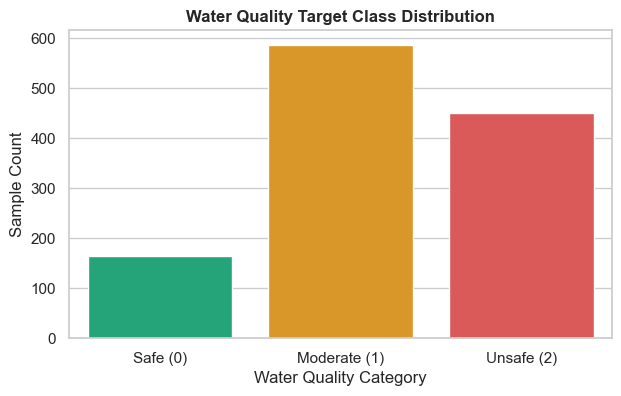

In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='water_quality', hue='water_quality', palette=['#10B981', '#F59E0B', '#EF4444'], legend=False)
plt.xticks([0, 1, 2], ['Safe (0)', 'Moderate (1)', 'Unsafe (2)'])
plt.title('Water Quality Target Class Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Water Quality Category')
plt.ylabel('Sample Count')

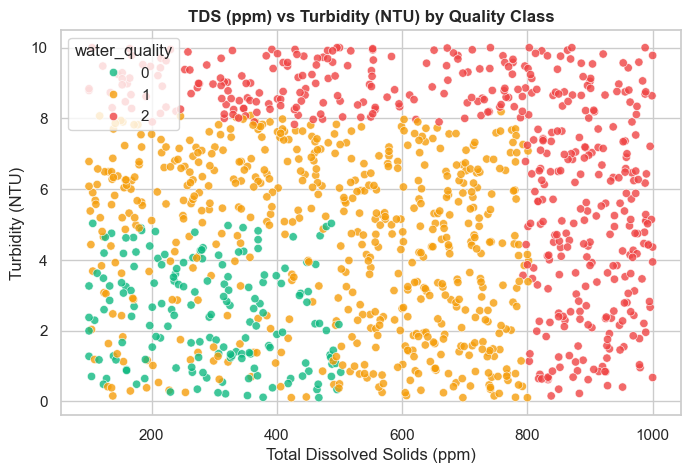

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='TDS_ppm', y='turbidity_NTU', hue='water_quality', palette=['#10B981', '#F59E0B', '#EF4444'], alpha=0.8)
plt.title('TDS (ppm) vs Turbidity (NTU) by Quality Class', fontsize=12, fontweight='bold')
plt.xlabel('Total Dissolved Solids (ppm)')
plt.ylabel('Turbidity (NTU)')

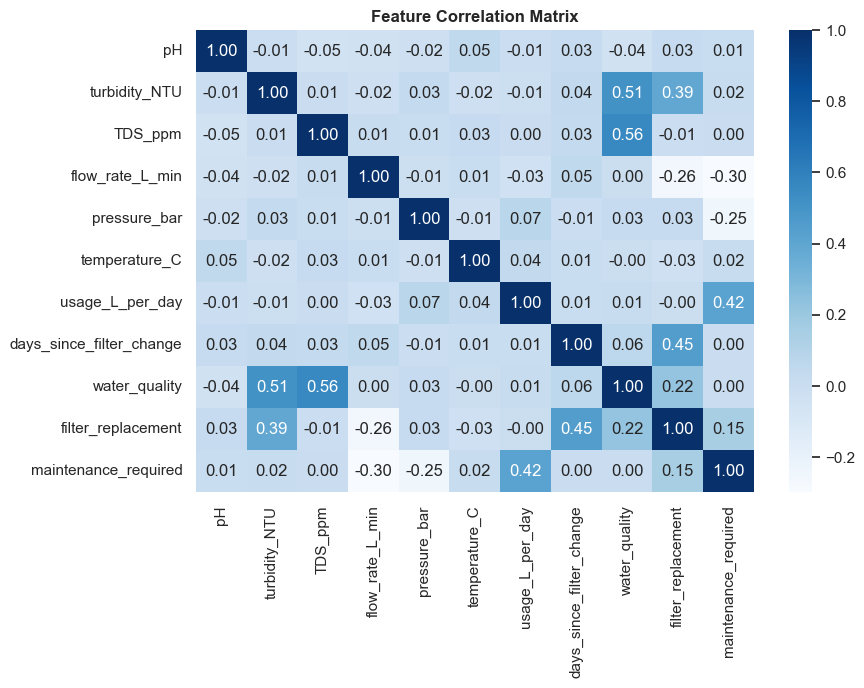

In [6]:
plt.figure(figsize=(9, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

## 3. Feature Selection & Train-Test Split


In [7]:
feature_cols = [
    "pH", "turbidity_NTU", "TDS_ppm", "flow_rate_L_min",
    "pressure_bar", "temperature_C", "usage_L_per_day", "days_since_filter_change"
]
target_col = "water_quality"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape    : {X_test.shape}")

Training set shape: (960, 8)
Test set shape    : (240, 8)


## 4. Feature Standardization (StandardScaler)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler fitted successfully on training data.")

StandardScaler fitted successfully on training data.


## 5. Candidate Model Benchmarking


In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=4, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("=== Candidate Model 5-Fold Cross-Validation Accuracy ===")
for name, model in models.items():
    if name in ["Logistic Regression", "AdaBoost", "Gradient Boosting"]:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name:20s} | 5-Fold CV Mean Accuracy: {scores.mean() * 100:.2f}%")

=== Candidate Model 5-Fold Cross-Validation Accuracy ===
Logistic Regression  | 5-Fold CV Mean Accuracy: 69.79%
Decision Tree        | 5-Fold CV Mean Accuracy: 95.42%
Random Forest        | 5-Fold CV Mean Accuracy: 94.79%
AdaBoost             | 5-Fold CV Mean Accuracy: 81.56%
Gradient Boosting    | 5-Fold CV Mean Accuracy: 96.35%


## 6. Final Model Training & Evaluation


In [10]:
final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=4,
    random_state=42
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("=" * 50)
print(f"  FINAL TEST ACCURACY : {acc * 100:.2f}%")
print(f"  Weighted Precision  : {prec:.4f}")
print(f"  Weighted Recall     : {rec:.4f}")
print(f"  Weighted F1-Score   : {f1:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Safe (0)", "Moderate (1)", "Unsafe (2)"]))

  FINAL TEST ACCURACY : 94.17%
  Weighted Precision  : 0.9436
  Weighted Recall     : 0.9417
  Weighted F1-Score   : 0.9412

Classification Report:
              precision    recall  f1-score   support

    Safe (0)       0.96      0.82      0.89        33
Moderate (1)       0.91      0.97      0.94       117
  Unsafe (2)       0.98      0.94      0.96        90

    accuracy                           0.94       240
   macro avg       0.95      0.91      0.93       240
weighted avg       0.94      0.94      0.94       240



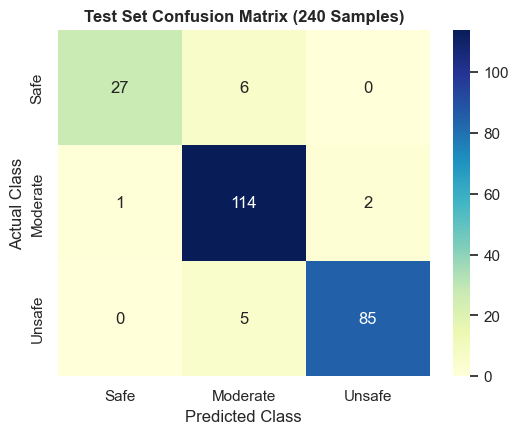

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=["Safe", "Moderate", "Unsafe"], yticklabels=["Safe", "Moderate", "Unsafe"])
plt.title('Test Set Confusion Matrix (240 Samples)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

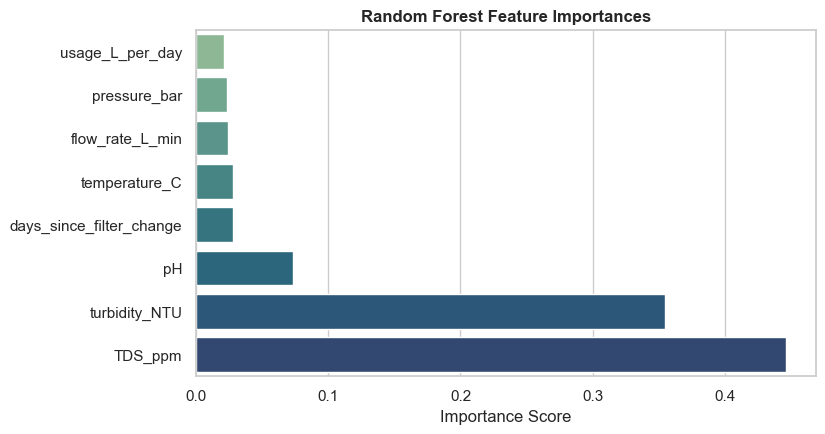

In [12]:
importances = final_model.feature_importances_
indices = np.argsort(importances)
sorted_feats = [feature_cols[i] for i in indices]
sorted_imps = importances[indices]

plt.figure(figsize=(8, 4.5))
sns.barplot(x=sorted_imps, y=sorted_feats, hue=sorted_feats, palette='crest', legend=False)
plt.title('Random Forest Feature Importances', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')

## 7. Model & Scaler Export


In [13]:
os.makedirs('models', exist_ok=True)

with open('models/model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
with open('model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Saved model.pkl and scaler.pkl successfully.")

Saved model.pkl and scaler.pkl successfully.


## 8. Sample Inference Verification


In [14]:
sample_input = pd.DataFrame([{
    "pH": 7.2,
    "turbidity_NTU": 2.0,
    "TDS_ppm": 300,
    "flow_rate_L_min": 1.0,
    "pressure_bar": 2.5,
    "temperature_C": 25.0,
    "usage_L_per_day": 20,
    "days_since_filter_change": 60
}])

predicted_code = final_model.predict(sample_input)[0]
predicted_probs = final_model.predict_proba(sample_input)[0]
label_map = {0: "Safe ✅", 1: "Moderate ⚠️", 2: "Unsafe ❌"}

print(f"Predicted Code  : {predicted_code}")
print(f"Predicted Status: {label_map[predicted_code]}")
print(f"Class Probabilities: Safe: {predicted_probs[0]:.2%}, Moderate: {predicted_probs[1]:.2%}, Unsafe: {predicted_probs[2]:.2%}")

Predicted Code  : 0
Predicted Status: Safe ✅
Class Probabilities: Safe: 79.43%, Moderate: 18.51%, Unsafe: 2.07%
